# 06 · One conversation, many questions

Notebook 05 answers one question well. This notebook makes a **conversation** out of it: many questions on the same
sandbox, each one cheap, each one knowing what came before, and nothing lost when the notebook or the sandbox restarts.

The whole idea in five lines:

1. **SQLite keeps everything** — every turn with its question, answer, all messages, tokens and cost (`turns` table).
2. **The model sees little** — the last `KEEP_TURNS` finished turns, each collapsed to *question → answer + one line
   saying what the turn did* (tools used, files written, variables created). No old tool calls, no old tool outputs.
3. **The present is queried, not remembered** — every question starts with a *sandbox state now* block: the variables
   in the kernel (type, shape, columns) with **what they hold in the model's own words**, the files of recent turns,
   memory and storage against their limits. After a sandbox restart the block says so, and the variables are gone.
4. **The answer has a shape, and it drives cleanup** — the model ends a turn with `answer` plus `kept_variables`
   (name + meaning). Pydantic AI validates it. When the turn ends, every variable that no turn in the window named
   is **deleted from the kernel**; the meanings are what the next question's state block shows beside each survivor.
   So a variable lives exactly as long as its story is in context, and the model never writes a `del`.
5. **Limits** — the per-question `LIMITS` of notebook 05 stay; before each question one `if` checks the conversation's
   total cost. A turn stopped by a limit is stored (its cost counts) but never shown to the model again.

Sections: 1 Tools · 2 Skills · 3 Store · 4 Sandbox state · 5 System prompt · 6 Answer shape, model, agent ·
7 History for the model · 8 `ask()` · 9 Try it · 10 Resume tomorrow · 11 Cleanup

In [1]:
import ast, json, os, re, sqlite3, sys
from collections import Counter
from datetime import datetime, timezone
os.environ["PYDANTIC_AI_NO_BANNER"] = "1"
from pathlib import Path
from IPython.display import Image, display
import pandas as pd
import pyarrow.parquet as pq

sys.path.insert(0, "../sandbox")
import sandbox as sb

CONVERSATION_ID = "conv_006"     # container name + folder conversation_data/conv_006/
KEEP_TURNS      = 5              # finished turns the model sees (question + answer + one-line record each)
CONV_COST_LIMIT = None           # USD for the whole conversation; None = no limit, only print the running total

## 1 · Tools

Copied from notebook 05; only the last line of a `run_python` result changed: memory used **of the limit**.

In [2]:
def run_python(code: str, timeout: int = 60) -> str:
    '''Run Python code in this conversation's sandbox (a persistent IPython kernel) and return what happened.
    Pre-imported: numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns.
    DATA = path of the AERONET AOD Level 2 daily parquet (read-only; Always read a column subset, the full table is ~1 GB; The system where the code executes is very lightweight).
    Variables persist between calls. No network. 2 GB RAM, 2 CPUs.
    What comes back, like a notebook cell:
    - stdout: everything you print(); stderr: warnings.
    - result: the value of the last expression if it is not an assignment (a DataFrame comes back as shape, dtypes,
      head and tail). Assign to a variable to suppress it.
    - stdout, stderr and result are each cut to 4000 characters (middle removed, marked "[N chars clipped]").
      Show only what you need: a small slice, .to_string() on a few rows, or aggregate first. Never print a whole
      table; save it as CSV under /workspace/ and report the file name.
    - Figures: save them yourself with fig.savefig('/workspace/<descriptive_name>.png'); any figure left open is
      auto-saved as fig_NNN.png. No plt.show(). All PNG names written by the cell are returned under figures.
    - new/changed variables with type and shape, files written, elapsed time and memory.
    Write any export (parquet, csv, png) under /workspace/.'''
    if not sb.running(CONVERSATION_ID):
        sb.start(CONVERSATION_ID)
    r = sb.exec_code(CONVERSATION_ID, code, timeout)
    out = []
    if r.get("stdout"):       out.append("stdout:\n" + r["stdout"].rstrip())
    if r.get("stderr"):       out.append("stderr:\n" + r["stderr"].rstrip())
    if r.get("error"):        out.append("ERROR: " + r["error"])
    if r.get("result"):       out.append("result:\n" + r["result"])
    if r.get("figures"):      out.append("figures saved: " + ", ".join(r["figures"]))
    if r.get("new_files"):    out.append("files written: " + ", ".join(r["new_files"]))
    if r.get("vars_new"):     out.append(f"new variables: {r['vars_new']}")
    if r.get("vars_changed"): out.append(f"changed variables: {r['vars_changed']}")
    if "elapsed_s" in r:      out.append(f"[{r['elapsed_s']} s | memory used {r['rss_mb']} of {r.get('memory_limit_mb')} MB]")
    return "\n".join(out) or "(no output)"


def kernel_state() -> str:
    '''Variables (type and shape), files in /workspace and memory use of this conversation's sandbox.'''
    return json.dumps(sb.state(CONVERSATION_ID), indent=1)


def reset_kernel() -> str:
    '''Delete all variables and open figures. Files in /workspace are kept.'''
    sb.reset(CONVERSATION_ID)
    return "kernel reset: no variables"


# ── two deterministic tools: computed on the host from the parquet, no LLM, no sandbox ──────────────
_SITES = None

def _sites():
    '''One row per site: location, record span, days with data. Read once (~10 s), then cached.'''
    global _SITES
    if _SITES is None:
        cols = ["AERONET_Site_Name", "Site_Latitude_Degrees", "Site_Longitude_Degrees", "Site_Elevation_m", "date"]
        df = pd.read_parquet(sb.PARQUET, columns=cols)
        g = df.groupby("AERONET_Site_Name")
        _SITES = pd.DataFrame({"lat": g["Site_Latitude_Degrees"].first().round(3),
                               "lon": g["Site_Longitude_Degrees"].first().round(3),
                               "elev_m": g["Site_Elevation_m"].first().round(0).astype(int),
                               "first": g["date"].min().dt.strftime("%Y-%m-%d"),
                               "last": g["date"].max().dt.strftime("%Y-%m-%d"),
                               "days": g.size()}).sort_values("days", ascending=False)
    return _SITES


def list_sites(name_contains: str = "", min_days: int = 0, limit: int = 40) -> str:
    '''Find AERONET sites. Returns name, latitude, longitude, elevation (m), first and last day with data, and the
    number of days with Level 2.0 data, sorted by record length. name_contains is case-insensitive
    (e.g. "kanpur", "GSFC", "_Island"). Use this before any site analysis to get the exact site name.'''
    s = _sites()
    if name_contains:
        s = s[s.index.str.contains(name_contains, case=False, regex=False)]
    s = s[s["days"] >= min_days]
    if s.empty:
        return f"no site matches name_contains={name_contains!r}, min_days={min_days}; try a shorter fragment"
    head = f"{len(s)} site(s) match" + (f", showing the {limit} with the longest records" if len(s) > limit else "") + "\n"
    return head + s.head(limit).to_string()


def _describe(col):
    if m := re.fullmatch(r"AOD_(\d+)nm", col):                       return f"aerosol optical depth at {m[1]} nm (unitless)"
    if m := re.fullmatch(r"Angstrom_Exponent_(\d+)_(\d+)nm(_Polar)?", col):
        return f"Ångström exponent {m[1]}–{m[2]} nm" + (" (polar instrument)" if m[3] else "")
    if m := re.fullmatch(r"N_(.+)", col):                             return f"number of measurements in the daily {m[1]}"
    return {"AERONET_Site_Name": "site name", "datetime_utc": "day stamp, 12:00 UTC", "date": "day",
            "year": "year", "month": "month", "Day_of_Year": "day of year 1–366",
            "Site_Latitude_Degrees": "latitude (deg)", "Site_Longitude_Degrees": "longitude (deg)",
            "Site_Elevation_m": "elevation (m)", "Precipitable_Water_cm": "column water vapour (cm)",
            "Data_Quality_Level": "always lev20", "AERONET_Instrument_Number": "sun-photometer id",
            "PI": "site principal investigator", "PI_Email": "PI e-mail"}.get(col, "")


def describe_columns(site: str = "") -> str:
    '''Columns of the AERONET table with meaning, dtype and how many days have a value.
    Without a site: every column (all sites). With a site (exact name from list_sites): only the columns that site
    has data for — call it once per site before choosing a wavelength. The N_<column> measurement-count columns
    are not listed one by one; every value column has one.'''
    pf = pq.ParquetFile(sb.PARQUET)
    if site:
        t = pq.read_table(sb.PARQUET, filters=[("AERONET_Site_Name", "==", site)])
        if t.num_rows == 0:
            return f"no site named {site!r}; use list_sites to find the exact name"
        n_days, nulls = t.num_rows, {c: t.column(c).null_count for c in t.column_names}
    else:
        n_days = pf.metadata.num_rows
        nulls = {c: 0 for c in pf.schema_arrow.names}
        for rg in range(pf.metadata.num_row_groups):
            for i in range(pf.metadata.num_columns):
                col = pf.metadata.row_group(rg).column(i)
                nulls[col.path_in_schema] += col.statistics.null_count if col.statistics else 0
    where = f"site {site}" if site else "all sites"
    lines = [f"{where}: {n_days} rows (site-days)" + ("; columns with no value at this site omitted" if site else ""),
             f"{'column':34} {'dtype':13} {'days_with_value':>15} {'cover':>6}  meaning"]
    for c in pf.schema_arrow.names:
        if c.startswith("N_"):
            continue
        have = n_days - nulls[c]
        if site and have == 0:
            continue
        lines.append(f"{c:34} {str(pf.schema_arrow.field(c).type):13} {have:>15} {100 * have / n_days:>5.1f}%  {_describe(c)}")
    lines.append("N_<column> (int16): number of Level 2.0 measurements averaged into that day's value; one per AOD, "
                 "Angstrom and Precipitable_Water column (0 -> value is NaN)")
    return "\n".join(lines)

## 2 · Skills

Copied from notebook 05 without change.

In [3]:
SKILLS = {}

SKILLS["data_access"] = """
WHEN: the first step of every analysis, before any statistic.
1. list_sites(name_contains=...) gives the exact site name (case-sensitive, underscores: "Mauna_Loa"), coordinates
   and record span; describe_columns(site=...) shows which wavelengths that site has and on how many days.
   Then load only the columns you need, filtered by site, e.g.
   pd.read_parquet(DATA, columns=["AERONET_Site_Name","date","year","month","AOD_500nm","N_AOD_500nm"],
                   filters=[("AERONET_Site_Name","==","GSFC")])
2. Describe the record before using it: days per year, gaps, and the coverage of the wavelength you chose (every
   column is NaN where that wavelength was not measured or failed Level 2.0 screening).
   Coverage is uneven: instruments are moved, break, and are recalibrated; gaps are normal, not errors.
3. One row = one day (daily mean of all Level 2.0 measurements of that day, stamped 12:00 UTC). N_<col> is how
   many measurements went into that mean; a day with N=1 is a real but weak estimate — say so if it matters.
4. Level 2.0 = cloud-screened AND quality-assured with final calibration (Version 3, Giles et al. 2019). You do not
   need extra cloud screening. Do not "clean" outliers: high AOD days are real events (dust, smoke).
5. Wavelengths: 500 nm is the standard reporting wavelength; 440/675/870/1020 nm are on every instrument;
   340/380 nm and 1640 nm only on some. AOD_531nm and AOD_551nm etc. are rarely populated. Check before use.
6. Keep memory small: never load all 73 columns for all sites at once (~1 GB); aggregate per site, then combine.
"""

SKILLS["climatology"] = """
WHEN: "typical", "average", "seasonal cycle", "monthly/annual mean", "how much AOD at site X".
1. Aggregate daily -> monthly means only when the month has enough days; default rule: >= 5 daily values per
   calendar month, and an annual mean needs >= 9 valid months. State the rule you used and how many months/years
   it removed.
2. AOD is right-skewed (roughly log-normal): report mean AND median (and the 10th/90th percentiles when
   describing variability). Use the mean for comparison with satellite/model climatologies, the median for
   "typical day". Ångström exponent is roughly symmetric; the mean is fine.
3. Seasonal cycle = group by calendar month across all years (multi-year monthly climatology); show N years per
   month. Standard deviation across years = interannual variability; std of daily values within the month = day-to-day
   variability. Say which one you plotted.
4. Multi-year climatologies over a changing record are biased if some years are missing whole seasons: check that
   each month-of-year is represented by a similar number of years, otherwise say so.
5. Plot: line or bar of the 12 monthly values with error bars (std or IQR), y-axis label "AOD 500 nm", title with
   site name and period, N per month annotated or in a table. Save under /workspace.
"""

SKILLS["trend"] = """
WHEN: "trend", "is AOD increasing/decreasing", "change over years", "long-term".
1. Requirements: >= 8 years of data with >= 9 valid months each; otherwise say the record is too short and stop at
   a description. Check for large gaps or an instrument change (AERONET_Instrument_Number) that splits the record.
2. Remove the seasonal cycle first: monthly means (>= 5 days) -> monthly anomalies = value minus the multi-year
   mean of that calendar month. Fit the trend to the anomaly time series with time in decimal years, NaN months
   dropped.
3. Use the Theil–Sen slope with the Mann–Kendall test (robust to the skewed distribution and outliers):
     from scipy import stats
     slope, intercept, lo, hi = stats.theilslopes(y, t, alpha=0.95)     # slope + 95 % confidence interval
     tau, p = stats.kendalltau(t, y)                                     # Mann–Kendall on a time series
   Cross-check with OLS that allows for autocorrelated residuals:
     import statsmodels.api as sm
     ols = sm.OLS(y, sm.add_constant(t)).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
   Report the OLS slope and its HAC p-value next to the Theil–Sen result; if they disagree on significance, say so.
4. Report: slope in AOD per year AND in % per year relative to the record mean, the confidence interval, n months
   used, p-value, the period. "Significant" = p < 0.05, and say so explicitly either way.
5. Caveats to state: monthly anomalies are autocorrelated (the Kendall p is optimistic, the HAC p is the honest
   one); a trend can be driven by the first or last years — plot the anomalies with the fitted line and look;
   attribution (emissions, dust, fires) is outside the data — do not claim causes.
"""

SKILLS["aerosol_type"] = """
WHEN: "what kind of aerosol", "dust or smoke", "fine vs coarse", "Ångström exponent", "AOD at 550 nm".
1. Use the Angstrom_Exponent_440_870nm column (computed per measurement from the spectral AOD, then averaged);
   do not recompute it from daily-mean AODs unless it is missing.
2. Interpretation (rule of thumb, Eck et al. 1999; Dubovik et al. 2002): AE < 0.75 -> coarse-mode dominated
   (desert dust, sea salt); AE > 1.5 -> fine-mode dominated (smoke, urban/industrial pollution); 0.75–1.5 -> mixed.
   Combined with AOD: high AOD (>= 0.4 at 500 nm) & low AE = dust event; high AOD & high AE = biomass burning or
   pollution; low AOD (< 0.1) & low AE = clean marine or background.
3. AE is noisy when AOD is low: exclude days with AOD_440nm < 0.15 before classifying, and say how many days that
   removed.
4. Show the AOD–AE relationship as a scatter (x = AE 440–870, y = AOD 500 nm, log y), colored by month or season,
   plus a table of the fraction of days in each class. This is a classification of daily means, not of single plumes.
5. AOD at a wavelength that is not measured (e.g. 550 nm): Ångström power law
   AOD(l) = AOD(500) * (l/500) ** (-AE) with AE = Angstrom_Exponent_440_870nm; valid only for 440–870 nm.
   Say that the value is interpolated.
"""

SKILLS["episodes"] = """
WHEN: "event", "episode", "extreme days", "dust storm", "smoke", "when was AOD highest".
1. "High" must be relative to the site's own climatology: flag a day when AOD 500 nm exceeds the site's
   multi-year 95th percentile for that calendar month (default), or a fixed value the user gives. State the
   threshold.
2. Group consecutive flagged days into episodes; report start, end, duration, peak AOD and its date, mean AE
   during the episode (for the likely aerosol type, see the aerosol_type skill), and N days.
3. Rank episodes by peak or by cumulative AOD above the threshold; list the top 10 as a table.
4. Show the daily series for the year(s) of interest with the threshold line and the episodes shaded.
5. A missing day inside an episode is likely cloud (no Level 2.0 data), not a gap in the event; say so rather than
   splitting the episode, unless the gap is > 2 days.
6. Do not name the source (a specific fire, storm) — the data cannot show it; describe timing, magnitude and type.
"""

SKILLS["site_comparison"] = """
WHEN: two or more sites, "compare", "regional", "which site is dustier", "difference between".
1. Compare only over the overlapping period and the same wavelength; state the common period and N days per site.
   If overlap < 2 years, compare climatologies instead and say they are from different years.
2. Report per site: coordinates, elevation, period, N, mean, median, 90th percentile of AOD 500 nm and mean AE
   440–870; then the difference of means/medians. Elevation matters: a mountain site (Mauna_Loa, Izana, > 2 km)
   sees only the free troposphere and is not comparable with a surface site nearby.
3. For paired daily differences use only days both sites have data (inner join on date).
4. Plots: same y-axis for all sites; monthly climatology lines on one axis, or box plots per site; a map (lon/lat
   scatter with site names) helps when there are more than 3 sites.
5. Distances between sites (haversine) belong in the answer when the user asks about "nearby".
"""

SKILLS_TEXT = "\n".join(f"### skill: {name}\n{text.strip()}\n" for name, text in SKILLS.items())
print(f"{len(SKILLS)} skills, {len(SKILLS_TEXT.split())} words")

6 skills, 1273 words


## 3 · Store

One SQLite file for all conversations, one table, one row per turn. `messages` holds every message of the turn as
Pydantic AI JSON (question, preambles, tool calls, tool outputs, answer) — that is the full trace. `variables` holds
the model's `kept_variables` (name + meaning) as JSON. `status` is `ok` or `stopped` (a usage limit hit).

In [4]:
DB = sqlite3.connect(sb.CONV_DIR / "conversations.sqlite")
DB.execute("""CREATE TABLE IF NOT EXISTS turns (
    conversation TEXT, turn INTEGER, asked TEXT, status TEXT,
    question TEXT, answer TEXT, summary TEXT, variables TEXT, kernel_note TEXT,
    requests INTEGER, tool_calls INTEGER, input_tokens INTEGER, cache_read INTEGER, cache_write INTEGER,
    output_tokens INTEGER, reasoning_tokens INTEGER, cost REAL,
    messages TEXT,
    PRIMARY KEY (conversation, turn))""")
if "variables" not in [r[1] for r in DB.execute("PRAGMA table_info(turns)")]:   # file created by the first version
    DB.execute("ALTER TABLE turns ADD COLUMN variables TEXT")

def save_turn(status, question, answer, summary, variables, kernel_note, usage, messages_json):
    turn = DB.execute("SELECT COUNT(*) FROM turns WHERE conversation=?", (CONVERSATION_ID,)).fetchone()[0] + 1
    DB.execute("INSERT INTO turns (conversation, turn, asked, status, question, answer, summary, variables, kernel_note, "
               "requests, tool_calls, input_tokens, cache_read, cache_write, output_tokens, reasoning_tokens, cost, messages) "
               "VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)",
               (CONVERSATION_ID, turn, datetime.now(timezone.utc).isoformat(timespec="seconds"), status,
                question, answer, summary, variables, kernel_note,
                usage.requests, usage.tool_calls, usage.input_tokens, usage.cache_read_tokens, usage.cache_write_tokens,
                usage.output_tokens, usage.details.get("reasoning_tokens", 0),
                float(usage.cost) if usage.cost is not None else None, messages_json))
    DB.commit()
    return turn

def finished_turns():
    '''(turn, question, answer, summary, variables) of the last KEEP_TURNS finished turns, oldest first.'''
    return DB.execute("SELECT turn, question, answer, summary, variables FROM turns WHERE conversation=? AND status='ok' "
                      "ORDER BY turn", (CONVERSATION_ID,)).fetchall()[-KEEP_TURNS:]

def conversation_cost():
    '''USD spent so far in this conversation, stopped turns included.'''
    return DB.execute("SELECT COALESCE(SUM(cost), 0) FROM turns WHERE conversation=?", (CONVERSATION_ID,)).fetchone()[0]

def show_turns():
    return pd.read_sql("SELECT turn, asked, status, question, summary, variables, kernel_note, requests, tool_calls, "
                       "input_tokens, cache_read, output_tokens, cost FROM turns WHERE conversation=? ORDER BY turn",
                       DB, params=(CONVERSATION_ID,))

In [5]:
finished_turns()

[(3,
  'Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.',
  '## Banizoumbou monthly climatology\n\n**Site:** Banizoumbou, **13.547° N, 2.665° E**, elevation 274 m. The full Level 2.0 record is **1995-10-16 to 2022-11-25** (**6,581 site-days**).\n\n| Month | Mean AOD 500 nm | AOD months / days | Mean Ångström exponent 440–870 nm | AE months / days |\n|---|---:|---:|---:|---:|\n| Jan | 0.281 | 1 / 28 | 0.41 | 26 / 631 |\n| Feb | 0.557 | 1 / 27 | 0.33 | 26 / 602 |\n| Mar | 1.458 | 1 / 33 | 0.21 | 23 / 530 |\n| Apr | 0.487 | 2 / 45 | 0.19 | 23 / 521 |\n| May | 0.499 | 2 / 41 | 0.16 | 23 / 534 |\n| Jun | 0.437 | 2 / 23 | 0.16 | 23 / 457 |\n| Jul | 0.323 | 1 / 26 | 0.33 | 22 / 425 |\n| Aug | 0.266 | 1 / 8 | 0.53 | 24 / 403 |\n| Sep | 0.318 | 2 / 33 | 0.47 | 25 / 506 |\n| Oct | 0.350 | 1 / 30 | 0.37 | 25 / 611 |\n| Nov | 0.198 | 2 / 38 | 0.42 | 26 / 675 |\n| Dec | 0.304 | 1 / 30 | 0.50 | 25 / 686 |\n\nThe figure shows the monthly means with standard

In [6]:
show_turns()

,turn,asked,status,question,summary,variables,kernel_note,requests,tool_calls,input_tokens,cache_read,output_tokens,cost
0,1,2026-09-28T04:07:22+00:00,ok,Which five sites have the longest AOD 500 nm r...,"tools: list_sites×1, describe_columns×5, run_p...","[{""name"": ""ranked"", ""meaning"": ""Top five sites...",NaN,5,8,39189,27873,1796,0.006063
1,2,2026-09-28T04:07:36+00:00,ok,"For the top one of those, what is its mean AOD...",tools: run_python×2 | files: mauna_loa_annual_...,[],NaN,3,2,18355,10690,2053,0.005033
2,3,2026-09-28T04:07:58+00:00,ok,Show the monthly climatology of AOD 500 nm and...,"tools: list_sites×1, describe_columns×1, run_p...",[],NaN,6,5,49095,37102,2825,0.007803
3,4,2026-09-28T04:08:07+00:00,ok,"What do we have so far, and what is left in th...",tools: kernel_state×1,[],"restarted (no reason recorded: memory limit, h...",2,1,13215,6395,647,0.002857
4,5,2026-09-28T16:15:41+00:00,ok,Which five sites have the longest AOD 500 nm r...,tools: run_python×1 | variables created: ranki...,[],NaN,2,1,14895,6870,766,0.003356
5,6,2026-09-28T16:16:43+00:00,ok,Show the monthly climatology of AOD 500 nm and...,tools: run_python×1 | variables created: Path ...,[],NaN,2,1,16036,7428,1202,0.004104
6,7,2026-09-28T16:17:39+00:00,ok,Show the monthly climatology of AOD 500 nm and...,"tools: list_sites×1, describe_columns×1, run_p...","[{""name"": ""clim"", ""meaning"": ""Banizoumbou mont...",NaN,4,3,37092,24516,2981,0.007906


In [7]:
conversation_cost()

0.037121733000000004

## 4 · Sandbox state

`ensure_running()` starts the sandbox when it is not running. If the conversation folder already existed, something
stopped the previous sandbox (60 idle minutes, storage cap, memory limit, `sb.stop`): the reason is remembered in
`KERNEL_NOTE` and told to the model **once**, in the next question.

`state_block()` asks the sandbox what it holds *right now* and is put on top of every question. The sandbox gives the
facts (name, type, shape, columns); the meanings come from the model's own `kept_variables` of earlier turns, joined
by name — a variable that no longer exists simply has nothing to join to, so nothing is ever rewritten after a
restart. Files: only those the last `KEEP_TURNS` turns produced (their answers explain them); after a restart,
everything on disk once, so the model knows what it can reload.

`cleanup_kernel()` runs after every finished turn: the variables named in `kept_variables` by any of the last
`KEEP_TURNS` turns survive, everything else is deleted. A turn-1 variable is gone after turn 6 unless a later turn
named it again — the same window as the history, so the kernel never holds a variable the model has no story for.

A restart is a boundary. `current_kernel_turns()` returns only the turns that ran on the kernel that is up now: none
while a restart is pending, otherwise those since the last stored restart note. Meanings and the cleanup use only
those; turns before the boundary keep their question, answer and files, and their variable lines are replaced by
"variables gone (sandbox restarted since)".

In [8]:
sb.running(CONVERSATION_ID)

False

In [10]:
ws = sb.CONV_DIR / CONVERSATION_ID
ws

PosixPath('/home/ubuntu/ai_for_aeronet/conversation_data/conv_006')

In [11]:
if ws.exists():                                                   # not the first start -> the old sandbox died
        killed = ws / "_killed.txt"
        reason = killed.read_text().strip() if killed.exists() else "no reason recorded: memory limit, host restart or stopped by hand"
        KERNEL_NOTE = f"restarted ({reason}); every earlier variable is gone, files in /workspace are kept"

In [ ]:
KERNEL_NOTE

'restarted (idle-stopped after 60 min without a request); every earlier variable is gone, files in /workspace are kept'

In [15]:
KERNEL_NOTE = None     # why the previous sandbox stopped; shown to the model in the next question, then cleared

def ensure_running():
    global KERNEL_NOTE
    if sb.running(CONVERSATION_ID):
        return
    ws = sb.CONV_DIR / CONVERSATION_ID
    if ws.exists():                                                   # not the first start -> the old sandbox died
        killed = ws / "_killed.txt"
        reason = killed.read_text().strip() if killed.exists() else "no reason recorded: memory limit, host restart or stopped by hand"
        KERNEL_NOTE = f"restarted ({reason}); every earlier variable is gone, files in /workspace are kept"
    sb.start(CONVERSATION_ID)

def current_kernel_turns():
    '''Finished turns that ran on the kernel that is up now: none if a restart is pending, else since the last restart note.'''
    if KERNEL_NOTE:
        return []
    boundary = DB.execute("SELECT COALESCE(MAX(turn), 0) FROM turns WHERE conversation=? AND kernel_note IS NOT NULL",
                          (CONVERSATION_ID,)).fetchone()[0]
    return [row for row in finished_turns() if row[0] >= boundary]

In [20]:
current_kernel_turns()

[(4,
  'What do we have so far, and what is left in the sandbox?',
  '## Sandbox status\n\nThe kernel was restarted, so **no Python variables remain in memory**. The files in `/workspace` survived.\n\n### Analyses completed\n\n1. **Five longest AOD 500 nm records**\n   - Ranked sites by the number of non-missing daily `AOD_500nm` values.\n   - Output table saved as `longest_aod500_records.csv`.\n\n2. **Mauna_Loa annual mean AOD 500 nm**\n   - Used the top-ranked site, Mauna_Loa.\n   - Applied the climatology rule of at least 5 valid daily values per month and at least 9 qualifying months per year.\n   - Output table saved as `mauna_loa_annual_mean_aod500.csv`.\n\n3. **Banizoumbou monthly climatology**\n   - Calculated monthly climatologies for AOD 500 nm and the reported Ångström exponent 440–870 nm.\n   - Saved both a table and figure.\n   - The AOD 500 nm record was sparse at Banizoumbou, so its monthly climatology represented mainly 2021–2022 rather than the full site record.\n\n###

In [21]:
def state_block():
    '''(text for the model, kernel note stored with the turn)'''
    global KERNEL_NOTE
    ensure_running()
    s = sb.state(CONVERSATION_ID)
    recent = finished_turns()
    meanings = {}                                                     # name -> meaning, later turns win
    for *_, variables in current_kernel_turns():
        for v in json.loads(variables or "[]"):
            meanings[v["name"]] = v["meaning"]
    lines = ["### sandbox state now"]
    if KERNEL_NOTE:
        lines.append(f"kernel: {KERNEL_NOTE}")
    if s["vars"]:
        lines.append("variables (name: type — what it holds):")
        lines += [f"  {k}: {v} — {meanings.get(k, 'not described')}" for k, v in s["vars"].items()]
    else:
        lines.append("variables: none")
    files = s["files"] if KERNEL_NOTE else [f for f in s["files"] if any(f in summary for *_, summary, _ in recent)]
    lines.append(("files in /workspace: " if KERNEL_NOTE else "files from recent turns: ") + (", ".join(files) or "none"))
    lines.append(f"memory used: {s['rss_mb']} of {s.get('memory_limit_mb')} MB; "
                 f"storage used: {s['workspace_mb']} of {s['workspace_cap_mb']} MB in /workspace")
    note, KERNEL_NOTE = KERNEL_NOTE, None
    return "\n".join(lines), note

def cleanup_kernel():
    '''Delete every variable that no turn in the window named in kept_variables. Returns (deleted, kept).'''
    keep = {v["name"] for *_, variables in current_kernel_turns() for v in json.loads(variables or "[]")}
    live = sb.state(CONVERSATION_ID)["vars"]
    drop = [k for k in live if k not in keep]
    if drop:
        sb.exec_code(CONVERSATION_ID, "del " + ", ".join(drop) + "\n__import__('gc').collect()")
    return drop, [k for k in live if k in keep]

In [22]:
print(state_block()[0])

### sandbox state now
kernel: restarted (idle-stopped after 60 min without a request); every earlier variable is gone, files in /workspace are kept
variables: none
files in /workspace: banizoumbou_monthly_climatology_aod500_ae440_870.csv, banizoumbou_monthly_climatology_aod500_ae440_870.png, banizoumbou_monthly_climatology_gt10_aod500_ae440_870.csv, banizoumbou_monthly_climatology_gt10_aod500_ae440_870.png, longest_aod500_records.csv, mauna_loa_annual_mean_aod500.csv
memory used: 198 of 2147 MB; storage used: 0.29 of 1000 MB in /workspace


## 5 · System prompt

Notebook 05's rules, data dictionary, environment, skills and preamble rule, plus one new block that explains the
conversation: what the state block is, that variables can vanish, memory, and the cleanup before the final answer.

In [ ]:
RULES = """
You are an atmospheric scientist analysing AERONET Level 2.0 aerosol optical depth (AOD) data with Python.
The data is a single parquet table in a sandbox you reach through the run_python tool. Work like an analyst:
- Look at the data before answering. Start with list_sites (exact name, coordinates, record span) and
  describe_columns(site) (which wavelengths that site measured); write code for the analysis, not for that.
  Never guess numbers.
- Follow the matching skill below step by step; say which skill and which thresholds you used.
- Small steps: one run_python call per step, check the output, then continue. Variables persist between calls.
- Tool output is cut at 4000 characters per field: print summaries and small slices, never whole tables;
  the last expression of a cell is returned as result, so end a cell with the object you want to see.
- Every answer states: site(s), coordinates, period used, wavelength, N (days/months/years), method, and caveats.
  AOD to 3 decimals, Ångström exponent to 2. "No data" is not zero.
- Figures: axis labels with units, title with site and period, legend; save each with fig.savefig under
  /workspace with a descriptive name and give the file name.
  Save tables you produce as CSV under /workspace and give the file name.
- Do not attribute causes (specific fires, policies, storms) that the data cannot show.
- If the question cannot be answered from this table (no such site, period outside the record, needs other data),
  say so plainly instead of approximating.
- AERONET data policy: results using a site's data should acknowledge the site PI (columns PI, PI_Email).
"""

CONVERSATION_RULES = """
### the conversation
- One sandbox serves the whole conversation. Every question starts with a "sandbox state now" block: the variables
  in the kernel (type, shape, columns) with what they hold as you described them earlier, the files recent turns
  produced, memory and storage against their limits. Earlier turns appear as question, answer and one line recording
  what that turn did. Only the state block is current; never assume a variable exists unless it is listed there.
- Variables live only while the sandbox is up: it stops after 60 idle minutes, or when memory or storage run out.
  Files in /workspace survive. When the block says the kernel restarted, rebuild what you need from those files or
  from the data.
- Variables: reuse what the state block lists when the new question needs it. You never write del. When a turn
  ends, every variable that none of the last 5 turns named in kept_variables is deleted automatically. So name in
  kept_variables only what a follow-up could reuse, under a descriptive name, with one line on what it holds
  (site, period, wavelength, unit); name an older variable again if it should stay alive. Temporaries, full-table
  loads and one-off slices are not named, so they disappear.
- Memory: every run_python result ends with memory used of the limit. Read only the columns you need, filtered by
  site; Python rarely gives memory back after deleting, so not loading it is the only real protection.
"""

DATA_DICTIONARY = """
### data dictionary — /data/aeronet.parquet (AERONET Version 3, Level 2.0, daily averages, all sites)
One row per site and day. Column names are AERONET's with ( ) [ ] - replaced by _.
- AERONET_Site_Name (str), Site_Latitude_Degrees, Site_Longitude_Degrees (decimal degrees), Site_Elevation_m (m)
- datetime_utc (12:00 UTC), date (datetime), year, month, Day_of_Year
- AOD_<λ>nm: aerosol optical depth at λ nm, unitless; NaN = not measured that day or failed Level 2.0 screening.
  Wavelengths present: 340, 380, 400, 412, 440, 443, 490, 500, 510, 532, 551, 555, 560, 620, 667, 675, 681, 709,
  779, 865, 870, 1020, 1640 (most sites: 340, 380, 440, 500, 675, 870, 1020).
- Angstrom_Exponent_<λ1>_<λ2>nm: Ångström exponent between λ1 and λ2 (340_440, 380_500, 440_675, 440_870,
  500_870; 440_675nm_Polar for polar instruments), unitless.
- Precipitable_Water_cm: column water vapour, cm.
- N_<column>: number of Level 2.0 measurements averaged into that day's value (0 -> value is NaN).
- Data_Quality_Level (always "lev20"), AERONET_Instrument_Number (sun-photometer id; changes = instrument swap),
  PI, PI_Email (site principal investigator).
"""

def environment_block():
    ensure_running()
    env = sb.env(CONVERSATION_ID)
    return ("### sandbox environment\n"
            f"python {env['python']}; packages: " + ", ".join(f"{k} {v}" for k, v in env["packages"].items()) + "\n"
            f"limits: {env['memory_limit_mb']} MB RAM, {env['cpus']} CPUs, {env['workspace_cap_gb']} GB in /workspace, no network\n"
            f"pre-loaded in the kernel:\n{env['preloaded']}\n")

PREAMBLE_RULE = """
### before every tool call
Whenever you call tools, first write ONE short sentence as normal text, before the tool calls, saying what you are
about to do and why. Several tools at once get a single sentence. Never call a tool without that sentence.
"""

INSTRUCTIONS = "\n".join([RULES.strip(), CONVERSATION_RULES.strip(), DATA_DICTIONARY.strip(), environment_block(),
                          "### skills\n" + SKILLS_TEXT, PREAMBLE_RULE.strip()])
print(f"{len(INSTRUCTIONS.split())} words ≈ {len(INSTRUCTIONS) // 4} tokens")

2051 words ≈ 3217 tokens


## 6 · Answer shape, model, agent

`output_type=Turn` makes the model end every question by calling a `final_result` tool with `answer` and
`kept_variables`. Pydantic AI validates the JSON and asks again if it is malformed (that is a retry and a request).
Tool output needs only tool calling, so it works for every model in the later comparison. Model and `LIMITS` as in
notebook 05; the conversation limit is the one `if` in `ask()`.

In [7]:
from pydantic import BaseModel, Field
from aws_bedrock_token_generator import provide_token
from pydantic_ai import Agent, Tool, UsageLimits, UsageLimitExceeded, RunUsage
from pydantic_ai.models.bedrock_mantle import BedrockMantleResponsesModel, BedrockMantleProvider
from pydantic_ai.models.openai import OpenAIResponsesModelSettings

class KeptVar(BaseModel):
    name: str    = Field(description="exact variable name in the kernel")
    meaning: str = Field(description="one line: what it holds (site, period, wavelength, unit) and why a follow-up could reuse it")

class Turn(BaseModel):
    answer: str                  = Field(description="the complete markdown answer, exactly as you would write it to the user")
    kept_variables: list[KeptVar] = Field(description="every variable you left in the kernel on purpose; temporaries are deleted")

REGION           = "us-west-2"
BASE_URL         = f"https://bedrock-runtime.{REGION}.amazonaws.com/openai/v1"
MODEL_ID         = "us.openai.gpt-5.6-luna"
REASONING_EFFORT = "medium"          # none | low | medium | high | xhigh | max

LIMITS = UsageLimits(
    request_limit      = 8,        # model calls per question (loop depth)
    tool_calls_limit   = 12,       # successful tool executions per question
    total_tokens_limit = 250_000,  # in + out, cumulative over the question
    cost_limit         = 0.10,     # USD per question
)
TOOL_TIMEOUT = 120                 # seconds; a slower tool = failure + retry prompt to the model

model = BedrockMantleResponsesModel(
    MODEL_ID,
    provider=BedrockMantleProvider(base_url=BASE_URL, api_key=provide_token(region=REGION)),
    settings=OpenAIResponsesModelSettings(max_tokens=8000, openai_reasoning_effort=REASONING_EFFORT,
                                          openai_prompt_cache_key="aeronet:v1"),
)

TOOLS = [Tool(run_python,   sequential=True),    # never two code calls at once on one kernel
         Tool(reset_kernel, sequential=True),
         kernel_state, list_sites, describe_columns]

agent = Agent(model, instructions=INSTRUCTIONS, tools=TOOLS, output_type=Turn, retries=2, tool_timeout=TOOL_TIMEOUT)
print(model.model_name, "via", model.client.base_url)

us.openai.gpt-5.6-luna via https://bedrock-runtime.us-west-2.amazonaws.com/openai/v1/


## 7 · History for the model

`history_for_model()` rebuilds the context from the store before every question: the last `KEEP_TURNS` finished
turns, each as one user message (the question) and one assistant message (the answer plus the one-line record).
`done_summary()` writes that record from the turn's own tool traffic — no model involved, so it is the same for
every model in the eval. Turns that ran before a sandbox restart lose their variable line: after a restart the model
is left with question, answer and files, plus the restart note with its reason.

In [23]:
from pydantic_ai.messages import (ModelMessagesTypeAdapter, ModelRequest, ModelResponse, UserPromptPart, TextPart,
                                  ThinkingPart, ToolCallPart, ToolReturnPart, RetryPromptPart)

def history_for_model():
    current = {turn for turn, *_ in current_kernel_turns()}
    history = []
    for turn, question, answer, summary, _ in finished_turns():
        if turn not in current:                                       # ran on a kernel that is gone
            summary = re.sub(r" \| variables created: .*$", "", summary) + " | variables gone (sandbox restarted since)"
        history.append(ModelRequest(parts=[UserPromptPart(content=question)]))
        history.append(ModelResponse(parts=[TextPart(content=f"{answer}\n\n[this turn did] {summary}")]))
    return history

def done_summary(messages):
    '''One line: tools called, files written, variables created — read off the tool calls and tool outputs.'''
    tools, files, created = Counter(), [], {}
    for m in messages:
        for p in m.parts:
            if isinstance(p, ToolCallPart) and p.tool_name != "final_result":
                tools[p.tool_name] += 1
            elif isinstance(p, ToolReturnPart) and isinstance(p.content, str):
                if p.tool_name == "reset_kernel":
                    created = {}
                for line in p.content.splitlines():
                    if line.startswith(("figures saved: ", "files written: ")):
                        files += line.split(": ", 1)[1].split(", ")
                    elif line.startswith("new variables: "):
                        try:    created.update(ast.literal_eval(line[len("new variables: "):]))
                        except Exception: pass
    out = ["tools: " + (", ".join(f"{k}×{v}" for k, v in tools.items()) or "none")]
    if files:   out.append("files: " + ", ".join(dict.fromkeys(files)))
    if created: out.append("variables created: " + ", ".join(f"{k} {v}" for k, v in created.items()))
    return " | ".join(out)

In [24]:
history_for_model()

[ModelRequest(parts=[UserPromptPart(content='Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.', timestamp=datetime.datetime(2026, 9, 29, 15, 57, 12, 265237, tzinfo=datetime.timezone.utc))]),
 ModelResponse(parts=[TextPart(content='## Banizoumbou monthly climatology\n\n**Site:** Banizoumbou, **13.547° N, 2.665° E**, elevation 274 m. The full Level 2.0 record is **1995-10-16 to 2022-11-25** (**6,581 site-days**).\n\n| Month | Mean AOD 500 nm | AOD months / days | Mean Ångström exponent 440–870 nm | AE months / days |\n|---|---:|---:|---:|---:|\n| Jan | 0.281 | 1 / 28 | 0.41 | 26 / 631 |\n| Feb | 0.557 | 1 / 27 | 0.33 | 26 / 602 |\n| Mar | 1.458 | 1 / 33 | 0.21 | 23 / 530 |\n| Apr | 0.487 | 2 / 45 | 0.19 | 23 / 521 |\n| May | 0.499 | 2 / 41 | 0.16 | 23 / 534 |\n| Jun | 0.437 | 2 / 23 | 0.16 | 23 / 457 |\n| Jul | 0.323 | 1 / 26 | 0.33 | 22 / 425 |\n| Aug | 0.266 | 1 / 8 | 0.53 | 24 / 403 |\n| Sep | 0.318 | 2 / 33 | 0.47 | 25 / 506 |\n| Oct | 0.350

In [26]:
done_summary(history_for_model()[:2])

'tools: none'

## 8 · `ask()`

Same printing loop as notebook 05. New around it, in order: the conversation-cost `if`, the state block on top of
the question, the rebuilt history, and at the end one row into the store — also when a limit stopped the turn
(`status='stopped'`, cost counted, never shown to the model again), then `cleanup_kernel()`. The `End` node carries a `Turn`.

In [9]:
from pydantic_graph import End

def show_part(p, preamble=False):
    if   isinstance(p, UserPromptPart): print(f"  >>> USER        : {p.content}")
    elif isinstance(p, ThinkingPart):   print(f"  ... THINKING    : {(p.content or '<no text>')}")
    elif isinstance(p, TextPart):       print(f"  <<< {'PREAMBLE' if preamble else 'ANSWER  '}    : {p.content}")
    elif isinstance(p, ToolCallPart):   print(f"  --> TOOL CALL   : {p.tool_name}({str(p.args)})")
    elif isinstance(p, ToolReturnPart): print(f"  <-- TOOL RESULT : {p.tool_name} -> {str(p.content)}")
    elif isinstance(p, RetryPromptPart):print(f"  !!! RETRY       : {p.tool_name}: {str(p.content)}")

def usage_line(u):
    cost = f"${u.cost:.4f}" if u.cost is not None else "cost n/a"
    return (f"in {u.input_tokens} (cache read {u.cache_read_tokens}, write {u.cache_write_tokens}) | "
            f"out {u.output_tokens} (reasoning {u.details.get('reasoning_tokens', 0)}) | {cost}")

def show_figures(messages):
    for m in messages:
        for p in m.parts:
            if isinstance(p, ToolReturnPart) and isinstance(p.content, str):
                for line in p.content.splitlines():
                    if line.startswith("figures saved: "):
                        for f in line[len("figures saved: "):].split(", "):
                            display(Image(sb.CONV_DIR / CONVERSATION_ID / f))

async def ask(question, limits=LIMITS):
    spent = conversation_cost()
    if CONV_COST_LIMIT is not None and spent >= CONV_COST_LIMIT:
        print(f"=== conversation budget used: ${spent:.4f} of ${CONV_COST_LIMIT}. Start a new CONVERSATION_ID.")
        return None
    ensure_running()                       # may set KERNEL_NOTE: history and state block below both act on it
    history = history_for_model()
    state, kernel_note = state_block()     # shows the note once and clears it
    print(f"=== {question}\n    ({len(history) // 2} earlier turns in context; conversation so far ${spent:.4f})")

    step, status = 0, "ok"
    async with agent.iter(f"{state}\n\n### question\n{question}", message_history=history, usage_limits=limits) as run:
        try:
            async for node in run:
                if Agent.is_model_request_node(node):
                    step += 1
                    print(f"\n--- step {step}: to model")
                    for p in node.request.parts: 
                        show_part(p)
                elif Agent.is_call_tools_node(node):
                    m = node.model_response
                    print(f"--- step {step}: from model")
                    for p in m.parts: 
                        show_part(p, preamble=bool(m.tool_calls))
                    print(f"      {usage_line(m.usage)}")
                elif isinstance(node, End):
                    print(f"\n=== ANSWER\n{node.data.output.answer}")
                    print("=== KEPT VARIABLES\n" + ("\n".join(f"  {v.name}: {v.meaning}" for v in node.data.output.kept_variables) or "  none"))
        except UsageLimitExceeded as e:
            status = "stopped"
            print(f"\n=== STOPPED: {e}\n    (cost counted; the model will not see this turn)")

    messages  = run.new_messages()
    out       = run.result.output if status == "ok" else None
    answer    = out.answer if out else None
    variables = json.dumps([v.model_dump() for v in out.kept_variables]) if out else None
    u         = run.usage
    turn = save_turn(status, question, answer, done_summary(messages), variables, kernel_note, u,
                     ModelMessagesTypeAdapter.dump_json(messages).decode())
    if status == "ok":
        show_figures(messages)
        deleted, kept = cleanup_kernel()
        print(f"\n=== KERNEL: kept {', '.join(kept) or 'nothing'} | deleted {', '.join(deleted) or 'nothing'}")
    print(f"\n=== TURN {turn} ({status}): {u.requests} model calls, {u.tool_calls} tool calls | {usage_line(u)}")
    print(f"=== CONVERSATION : ${conversation_cost():.4f}" + (f" of ${CONV_COST_LIMIT}" if CONV_COST_LIMIT else ""))
    return run.result

In [10]:
import re, base64, mimetypes
from IPython.display import Markdown

def render(text):
    '''Model markdown -> displayable markdown: sandbox:/workspace/X links become real files, PNGs inline.'''
    def sub(m):
        label, name = m.group(1), m.group(2)
        f = sb.CONV_DIR / CONVERSATION_ID / name
        if f.suffix.lower() in (".png", ".jpg", ".jpeg") and f.exists():
            b64 = base64.b64encode(f.read_bytes()).decode()
            return f"![{label}](data:{mimetypes.guess_type(name)[0]};base64,{b64})"
        return f"`{f}`" + ("" if f.exists() else " (missing)")
    return re.sub(r"\[([^\]]*)\]\(sandbox:/workspace/([^)\s]+)\)", sub, text)

def answer(result):
    '''Pretty view of one finished question.'''
    display(Markdown(render(result.output.answer)))

## 9 · Try it

Three questions: a first analysis, a follow-up that should reuse its variables, and an unrelated one that should
free them. Then the sandbox is stopped by hand to stand in for 60 idle minutes, and the next question shows the
restart note. Watch the `>>> USER` line of each step 1: that is the state block the model gets.

In [11]:
r = await ask("Which five sites have the longest AOD 500 nm records, and how many days of data does each have?")

=== Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
    (4 earlier turns in context; conversation so far $0.0218)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables: none
files from recent turns: banizoumbou_monthly_climatology_aod500_ae440_870.csv, banizoumbou_monthly_climatology_aod500_ae440_870.png, longest_aod500_records.csv, mauna_loa_annual_mean_aod500.csv
memory used: 205 of 2147 MB; storage used: 0.15 of 1000 MB in /workspace

### question
Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll read the saved ranking table to report the five sites and their valid AOD 500 nm day counts without reloading the full parquet dataset.
  --> TOOL CALL   : run_python({"code":"ranking = pd.read_csv('/workspace/longest_aod500_records.csv')\nprint(ranking.to_string(index=False))\nranking"})
      in 6991

In [12]:
answer(r)

## Five longest AOD 500 nm records

| Rank | Site | Coordinates (°) | First–last valid AOD date | N (days) |
|---:|---|---:|---|---:|
| 1 | Mauna_Loa | 19.536006° N, 155.576755° W | 1995-03-16 to 2026-07-07 | 9,152 |
| 2 | GSFC | 38.992500° N, 76.839833° W | 1995-03-24 to 2026-01-08 | 7,973 |
| 3 | SEDE_BOKER | 30.855000° N, 34.782222° E | 1997-09-25 to 2025-04-04 | 7,706 |
| 4 | Izana | 28.309320° N, 16.499060° W | 1997-06-15 to 2026-01-27 | 6,375 |
| 5 | Sevilleta | 34.354721° N, 106.885002° W | 1995-07-06 to 2025-03-26 | 6,204 |

**Method:** I reused the saved ranking from the **data-access skill**. Sites were ranked by the count of non-missing daily `AOD_500nm` values in AERONET Version 3 Level 2.0 data. Wavelength: **500 nm**. The displayed dates are the first and last valid observations; they do not imply continuous coverage. Missing values were excluded, not treated as zero. Each value is a daily mean of Level 2.0 measurements, stamped at 12:00 UTC.

The source table is saved as `/home/ubuntu/ai_for_aeronet/conversation_data/conv_006/longest_aod500_records.csv`.

**Site PI acknowledgment:** Mauna_Loa — Pawan Gupta and Elena Lind; GSFC — Pawan Gupta and Elena Lind; SEDE_BOKER — Arnon Karnieli; Izana — Emilio Cuevas-Agullo and Africa Barreto; Sevilleta — Pawan Gupta.

In [13]:
r = await ask("For the top one of those, what is its mean AOD 500 nm per year? Reuse what you already have.")

=== For the top one of those, what is its mean AOD 500 nm per year? Reuse what you already have.
    (1 earlier turns in context; conversation so far $0.0061)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables (name: type — what it holds):
  ranked: DataFrame(5, 6)[AERONET_Site_Name, days_AOD500, first_AOD500, last_AOD500, latitude, longitude] — Top five sites ranked by valid AOD 500 nm daily observations, with first/last dates and coordinates.
  out: DataFrame(5, 6)[AERONET_Site_Name, days_AOD500, first_AOD500, last_AOD500, latitude, longitude] — CSV-ready version of the top-five AOD 500 nm record table.
files from recent turns: longest_aod500_records.csv
memory used: 639 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace

### question
For the top one of those, what is its mean AOD 500 nm per year? Reuse what you already have.
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll reuse the ranked top site, load only its date and AOD 5

In [14]:
answer(r)

## Mauna_Loa annual mean AOD

The top-ranked site is **Mauna_Loa** (**19.536006° N, 155.576755° W**). Using **AOD 500 nm** Level 2.0 daily data over **1995-03-16 to 2026-07-07**, I calculated monthly means first and then annual means from the qualifying monthly means.

| Year | Mean AOD 500 nm | Qualifying months | Valid days |
|---:|---:|---:|---:|
| 1997 | 0.020 | 11 | 134 |
| 1998 | 0.015 | 12 | 252 |
| 1999 | 0.018 | 12 | 248 |
| 2000 | 0.016 | 12 | 287 |
| 2001 | 0.017 | 12 | 317 |
| 2002 | 0.016 | 12 | 304 |
| 2003 | 0.018 | 12 | 323 |
| 2004 | 0.017 | 12 | 286 |
| 2005 | 0.020 | 12 | 320 |
| 2006 | 0.018 | 12 | 304 |
| 2007 | 0.018 | 12 | 310 |
| 2008 | 0.022 | 12 | 313 |
| 2009 | 0.024 | 12 | 311 |
| 2010 | 0.019 | 12 | 330 |
| 2011 | 0.026 | 12 | 293 |
| 2012 | 0.020 | 12 | 325 |
| 2013 | 0.018 | 12 | 308 |
| 2014 | 0.017 | 12 | 310 |
| 2015 | 0.016 | 12 | 339 |
| 2016 | 0.017 | 12 | 317 |
| 2017 | 0.017 | 12 | 331 |
| 2018 | 0.023 | 12 | 289 |
| 2019 | 0.018 | 12 | 329 |
| 2020 | 0.020 | 12 | 323 |
| 2021 | 0.020 | 12 | 321 |
| 2022 | 0.032 | 12 | 333 |
| 2023 | 0.015 | 12 | 306 |
| 2024 | 0.018 | 12 | 338 |
| 2025 | 0.022 | 12 | 330 |

**Coverage:** 29 qualifying years and 366 qualifying months, based on 9,152 valid daily AOD observations overall. The years **1995** and **1996** were excluded because they had only 5 and 7 qualifying months, respectively. **2026** was excluded because it is incomplete, with 7 qualifying months. The rule used was **at least 5 valid daily observations per month** and **at least 9 valid months per year**.

**Method:** climatology skill; monthly arithmetic means followed by an unweighted mean of qualifying monthly means for each year. Missing values were excluded, not treated as zero. These are daily Level 2.0 AERONET means, so gaps and uneven daily coverage remain possible. No trend or causal interpretation is implied.

CSV: `/home/ubuntu/ai_for_aeronet/conversation_data/conv_006/mauna_loa_annual_mean_aod500.csv`

**Site PI acknowledgment:** Mauna_Loa data are associated with the site PIs **Pawan Gupta and Elena Lind**.

In [13]:
r = await ask("Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.")

=== Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.
    (5 earlier turns in context; conversation so far $0.0251)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables: none
files from recent turns: banizoumbou_monthly_climatology_aod500_ae440_870.csv, banizoumbou_monthly_climatology_aod500_ae440_870.png, longest_aod500_records.csv, mauna_loa_annual_mean_aod500.csv
memory used: 207 of 2147 MB; storage used: 0.15 of 1000 MB in /workspace

### question
Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll read the saved Banizoumbou climatology table and verify the existing figure so I can reproduce the monthly summary without reloading the full parquet dataset.
  --> TOOL CALL   : run_python({"code":"from pathlib import Path\ncsv_path = '/workspace/banizoumbou_monthly_climatology_aod500_ae440_870.csv'\nfig_path

## Banizoumbou monthly climatology

**Site:** Banizoumbou (**13.547° N, 2.665° E; elevation 274 m**)  
**Site record:** 1995-10-16 to 2022-11-25.  
**Wavelength:** AOD at **500 nm**; Ångström exponent between **440 and 870 nm**.

| Month | Mean AOD 500 nm | AOD months / days | Mean Ångström exponent 440–870 nm | AE months / days |
|---|---:|---:|---:|---:|
| Jan | 0.281 | 1 / 28 | 0.41 | 26 / 631 |
| Feb | 0.557 | 1 / 27 | 0.33 | 26 / 602 |
| Mar | 1.458 | 1 / 33 | 0.21 | 23 / 530 |
| Apr | 0.487 | 2 / 45 | 0.19 | 23 / 521 |
| May | 0.499 | 2 / 41 | 0.16 | 23 / 534 |
| Jun | 0.437 | 2 / 23 | 0.16 | 23 / 457 |
| Jul | 0.323 | 1 / 26 | 0.33 | 22 / 425 |
| Aug | 0.266 | 1 / 8 | 0.53 | 24 / 403 |
| Sep | 0.318 | 2 / 33 | 0.47 | 25 / 506 |
| Oct | 0.350 | 1 / 30 | 0.37 | 25 / 611 |
| Nov | 0.198 | 2 / 38 | 0.42 | 26 / 675 |
| Dec | 0.304 | 1 / 30 | 0.50 | 25 / 686 |

!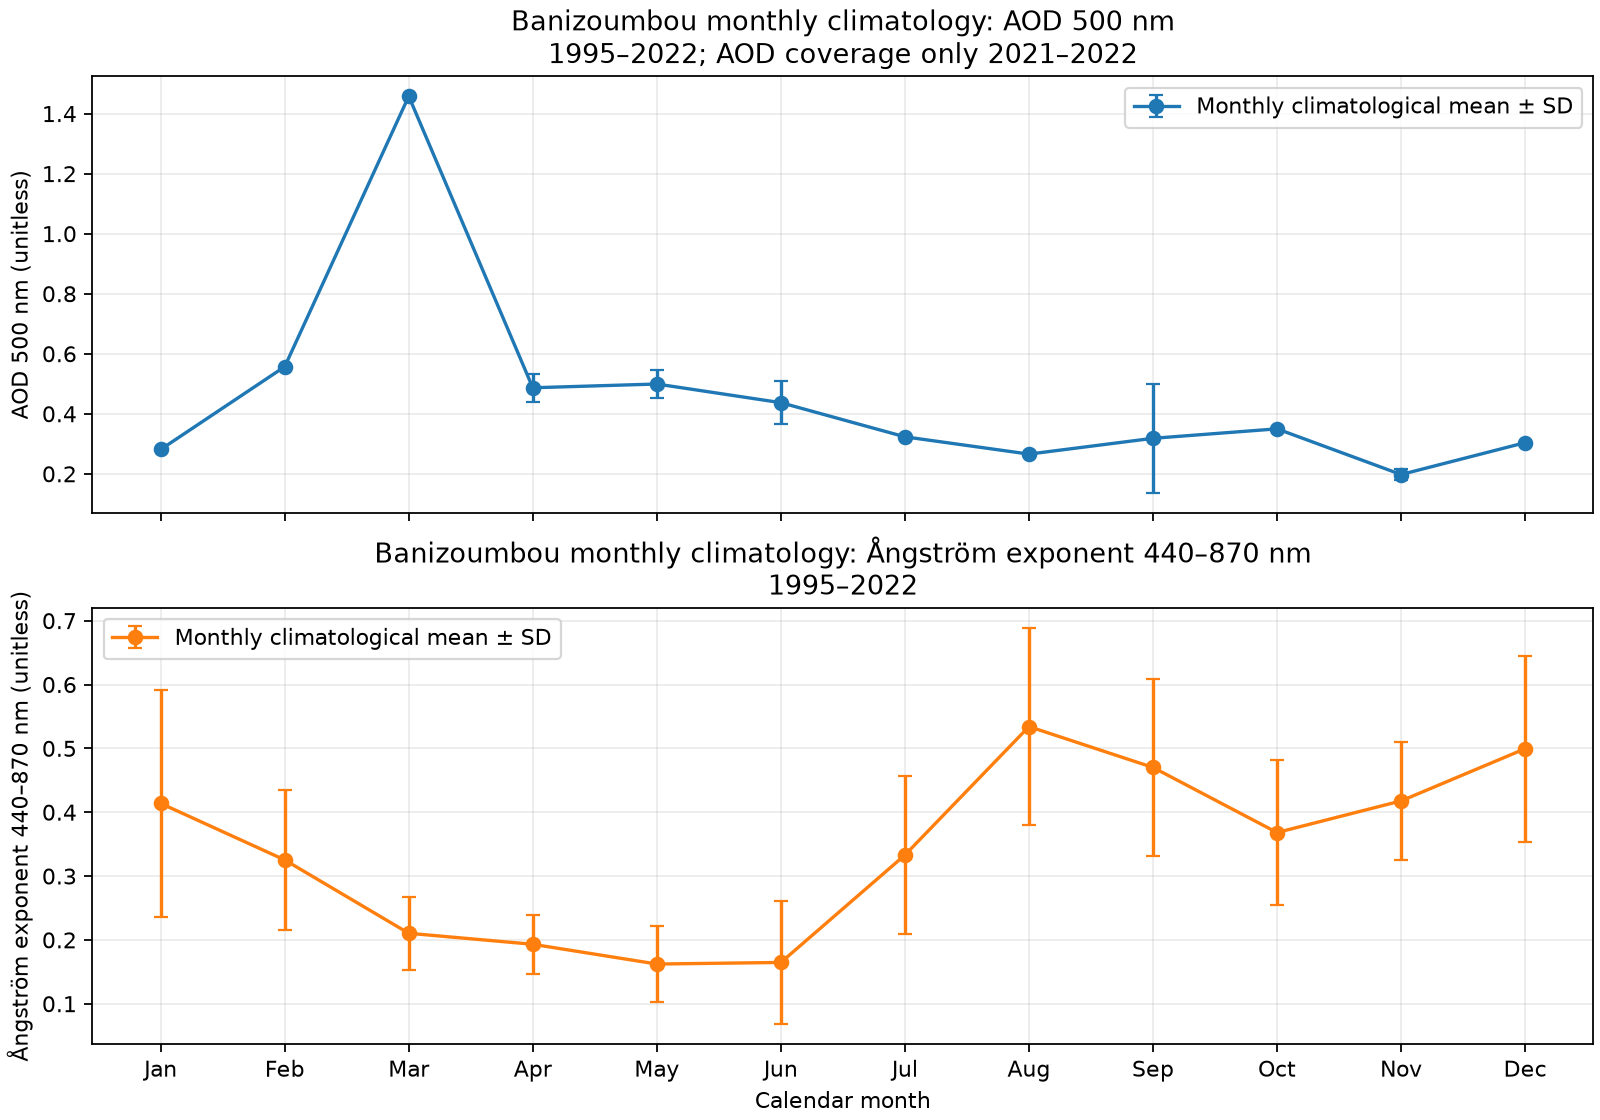

### Method and caveats

I used the **climatology skill**. Daily Level 2.0 values were first averaged into calendar-month means, retaining a month only when it had **at least 5 valid daily values**. The monthly climatology is the mean of those qualifying monthly means. Ångström exponent uses AERONET’s reported `Angstrom_Exponent_440_870nm` values rather than being recomputed from daily mean AODs. Missing values were excluded, not treated as zero.

- **AOD 500 nm:** 362 valid daily values and 17 qualifying monthly values, concentrated in **2021–2022**. It is therefore a sparse two-year summary, not a climatology representative of the full 1995–2022 site record.
- **Ångström exponent:** 6,581 valid daily values and 291 qualifying monthly values over the longer record, with uneven coverage.
- Standard deviations were not displayed in the table; months with only one qualifying year have no interannual standard deviation.

Files: `/home/ubuntu/ai_for_aeronet/conversation_data/conv_006/banizoumbou_monthly_climatology_aod500_ae440_870.csv` · 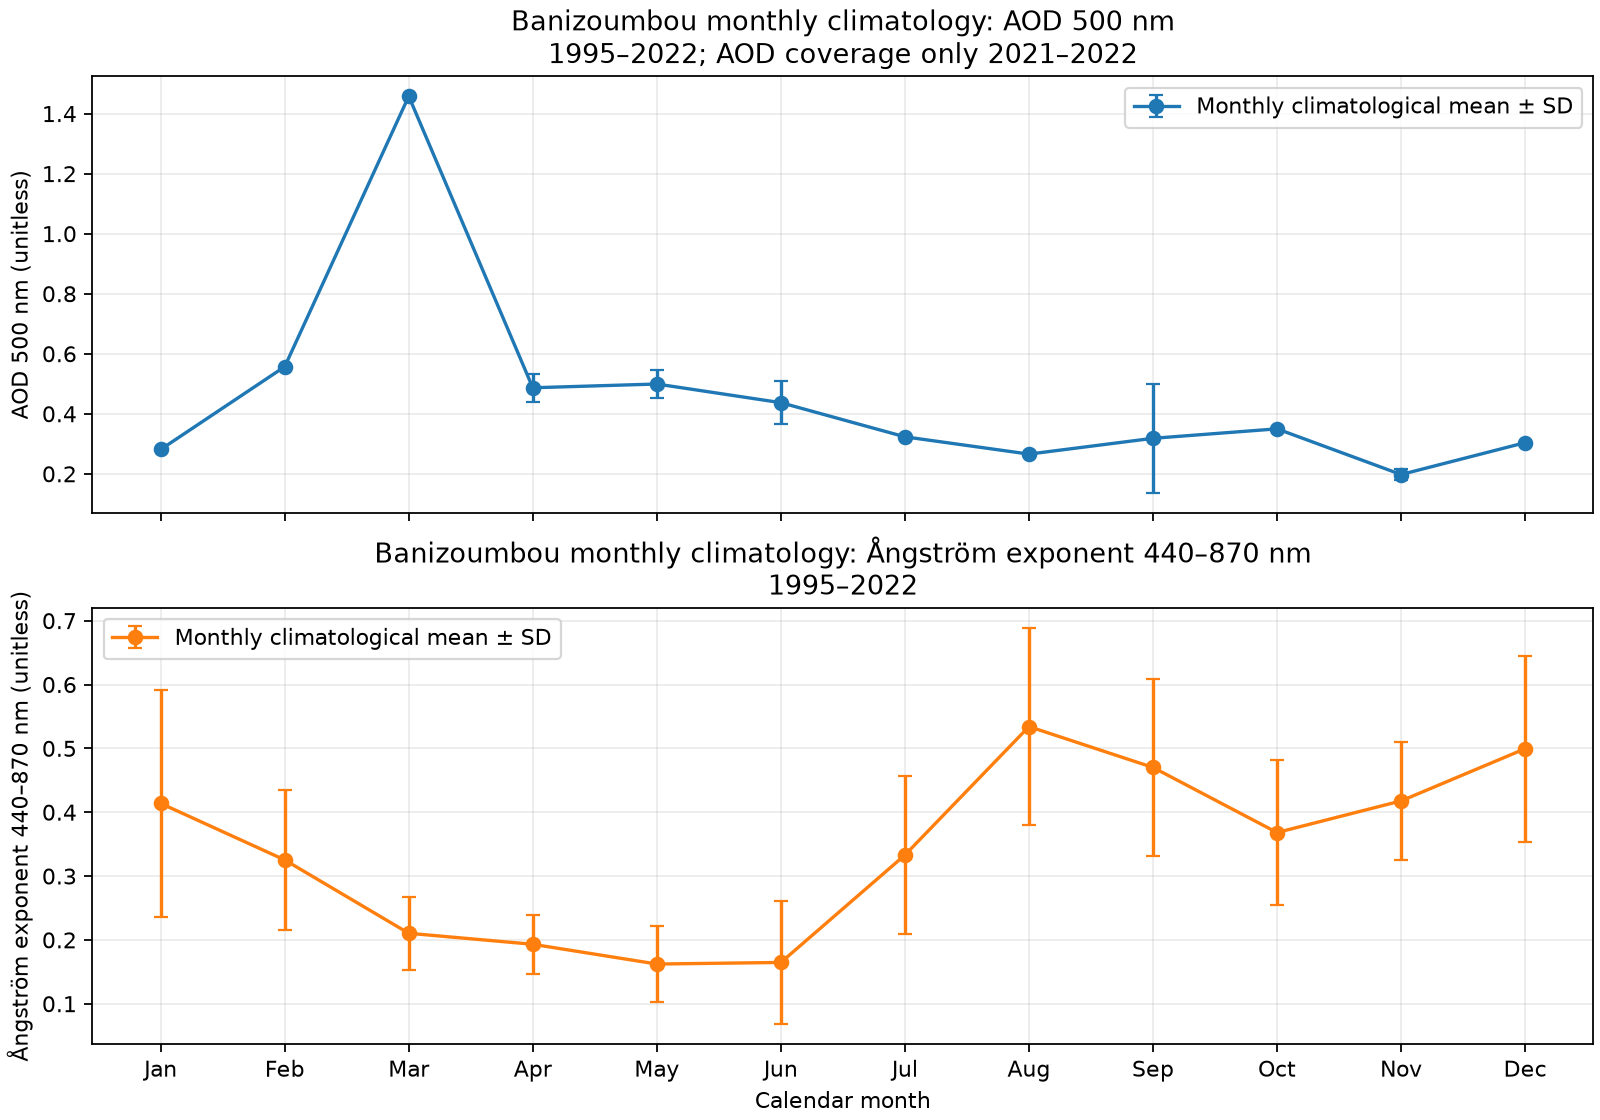

**Site PI acknowledgment:** Jean-Louis Rajot, Banizoumbou site PI.

In [14]:
answer(r)

=== Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou. Only consider month with more than 10 days of data!
    (5 earlier turns in context; conversation so far $0.0292)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables: none
files from recent turns: banizoumbou_monthly_climatology_aod500_ae440_870.csv, banizoumbou_monthly_climatology_aod500_ae440_870.png, mauna_loa_annual_mean_aod500.csv
memory used: 207 of 2147 MB; storage used: 0.15 of 1000 MB in /workspace

### question
Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou. Only consider month with more than 10 days of data!
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll verify Banizoumbou’s exact site record and coordinates before recalculating the climatology with the stricter threshold.
  --> TOOL CALL   : list_sites({"name_contains":"Banizoumbou","limit":10})
      in 7878 (cache read 0, write 7757

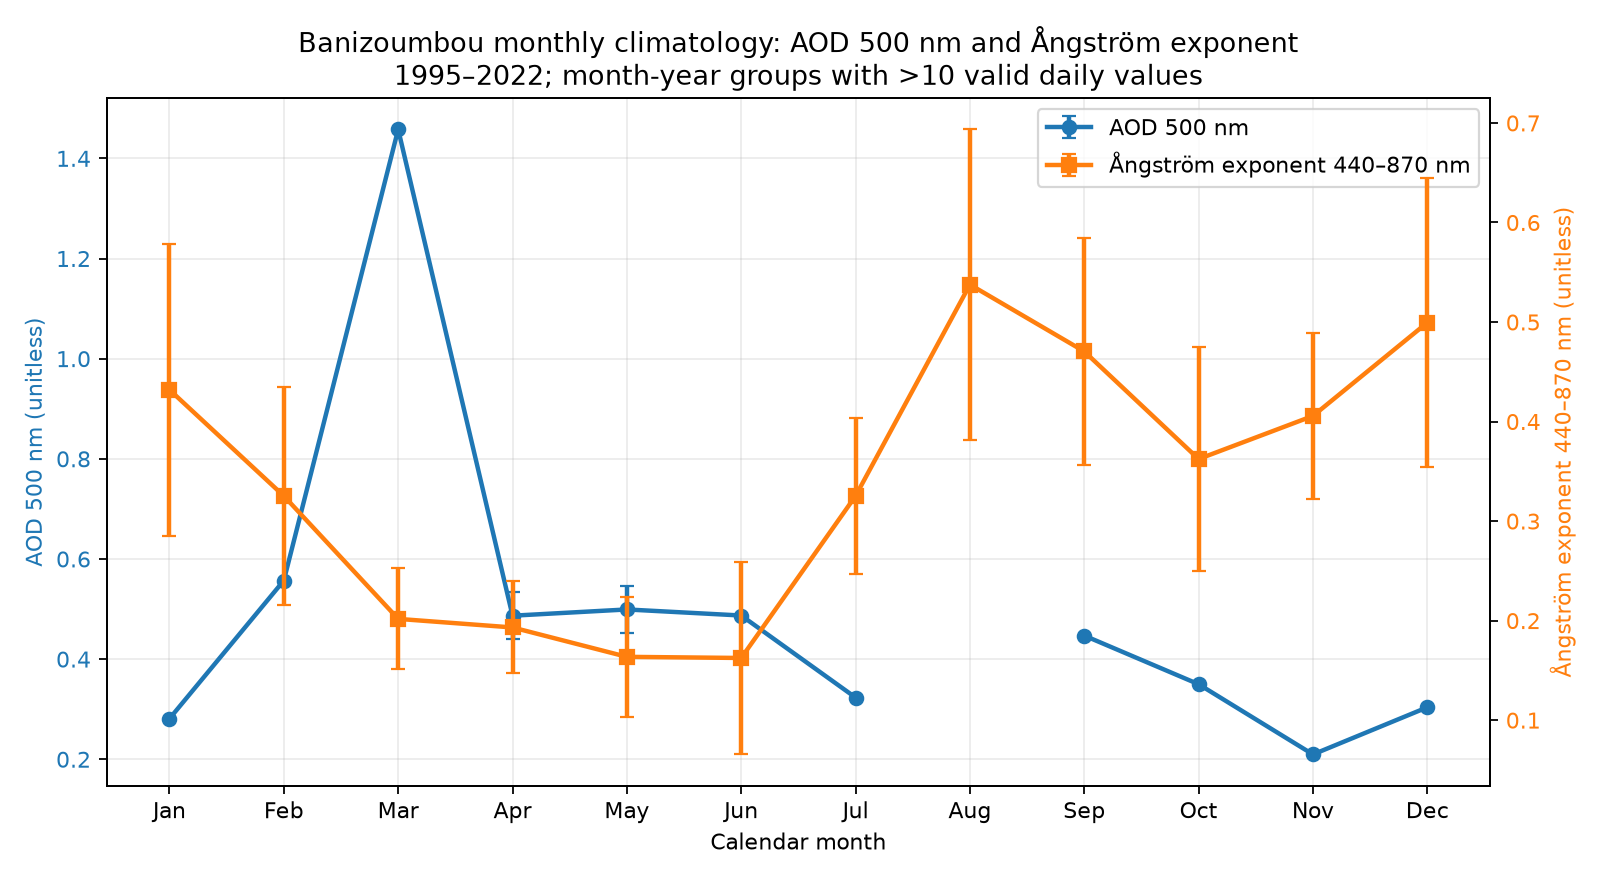


=== KERNEL: kept clim | deleted site, cols, df, monthly_aod, monthly_ae, clim_aod, clim_ae, site_days, aod_days, ae_days, years, fig, ax1, x, aod, aodsd, ae, aesd, ax2, lines, labels, lines2, labels2

=== TURN 7 (ok): 4 model calls, 3 tool calls | in 37092 (cache read 24516, write 12092) | out 2981 (reasoning 532) | $0.0079
=== CONVERSATION : $0.0371


In [15]:
r = await ask("Show the monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou. Only consider month with more than 10 days of data!")

## Banizoumbou monthly climatology (>10 valid days per month)

**Site:** Banizoumbou, **13.547° N, 2.665° E**, elevation 274 m  
**Record period:** 1995-10-16 to 2022-11-25  
**Wavelengths:** AOD **500 nm** and Ångström exponent **440–870 nm**

| Month | Mean AOD 500 nm | AOD qualifying month-years / days | Mean Ångström exponent 440–870 nm | AE qualifying month-years / days |
|---|---:|---:|---:|---:|
| Jan | 0.281 | 1 / 28 | 0.43 | 24 / 615 |
| Feb | 0.557 | 1 / 27 | 0.33 | 26 / 602 |
| Mar | 1.458 | 1 / 29 | 0.20 | 21 / 515 |
| Apr | 0.487 | 2 / 45 | 0.19 | 23 / 517 |
| May | 0.499 | 2 / 41 | 0.16 | 22 / 522 |
| Jun | 0.487 | 1 / 15 | 0.16 | 19 / 429 |
| Jul | 0.323 | 1 / 22 | 0.33 | 19 / 396 |
| Aug | No data | 0 / 0 | 0.54 | 22 / 387 |
| Sep | 0.447 | 1 / 26 | 0.47 | 22 / 485 |
| Oct | 0.350 | 1 / 28 | 0.36 | 24 / 602 |
| Nov | 0.210 | 1 / 29 | 0.41 | 24 / 656 |
| Dec | 0.304 | 1 / 30 | 0.50 | 25 / 686 |

!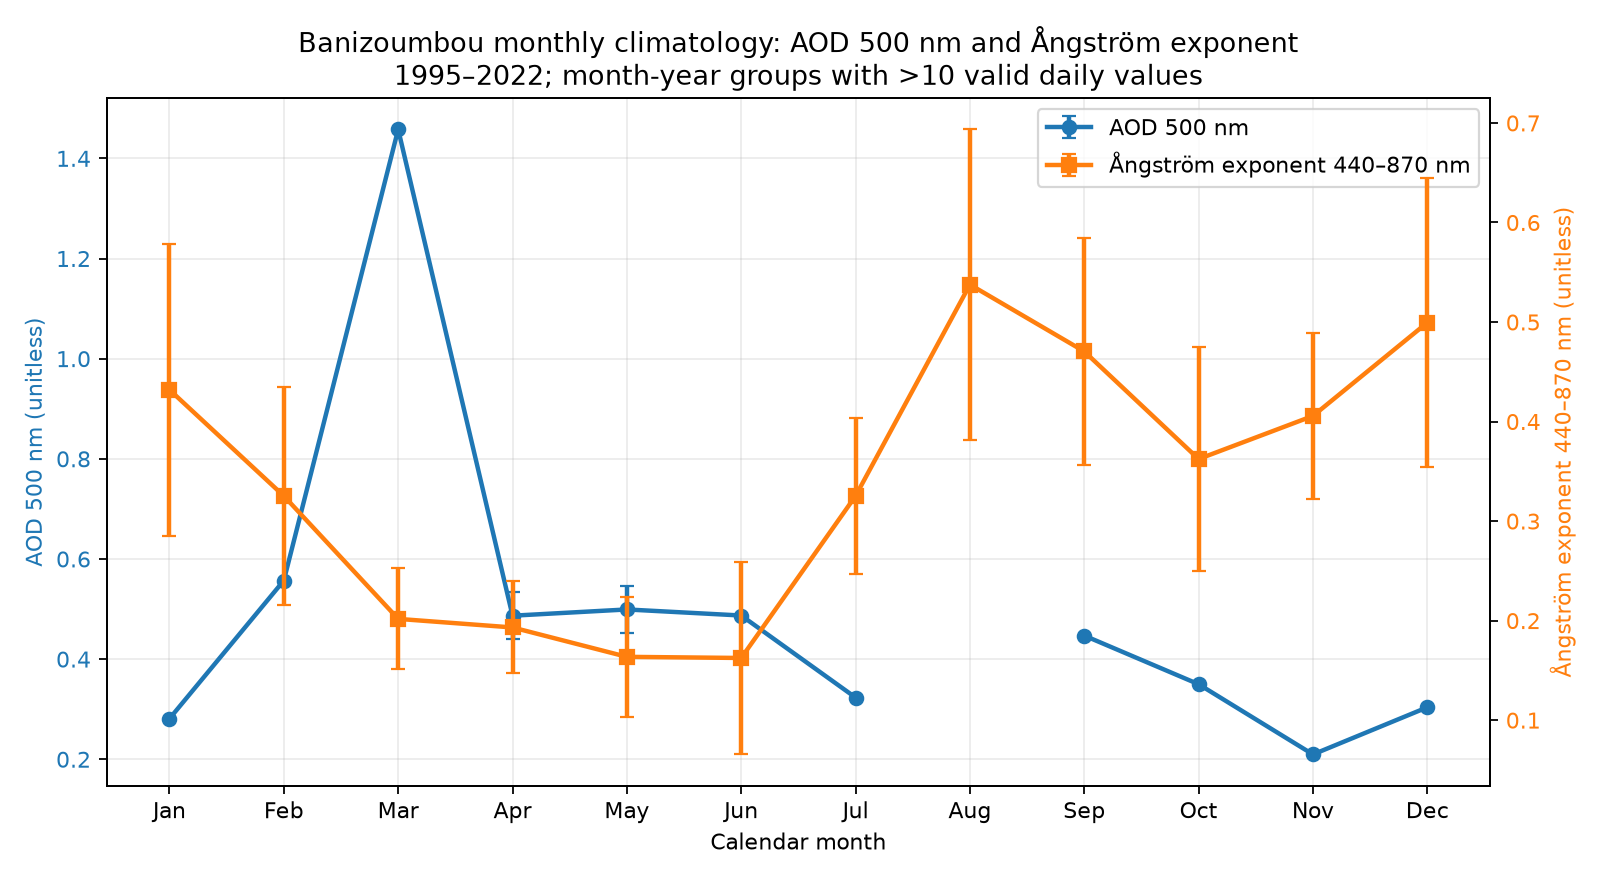

### Method and coverage

I used the **climatology skill**, with the requested stricter criterion: a calendar month in a particular year was retained only when it had **more than 10 valid daily values**, i.e. at least **11 days**. The monthly climatology is the arithmetic mean across those qualifying month-years. AOD and Ångström exponent were filtered independently. The Ångström exponent uses AERONET’s reported `Angstrom_Exponent_440_870nm` product, not a recalculation from daily AOD.

- **AOD 500 nm:** 13 qualifying month-years and **320 retained days** out of 362 valid days overall. August has no qualifying AOD month-year. Because AOD 500 nm is available at this site mainly during a short instrument period, these values are a sparse summary rather than a climatology representative of the full 1995–2022 record.
- **Ångström exponent:** 271 qualifying month-years and **6,412 retained days** out of 6,581 valid days overall.
- Standard deviations across qualifying years were plotted as error bars; they are undefined for months with only one qualifying year. Missing data were excluded, not treated as zero.
- These are daily Level 2.0 means, so the counts are days, not individual measurements. No causal interpretation is implied.

Files: `/home/ubuntu/ai_for_aeronet/conversation_data/conv_006/banizoumbou_monthly_climatology_gt10_aod500_ae440_870.csv` · 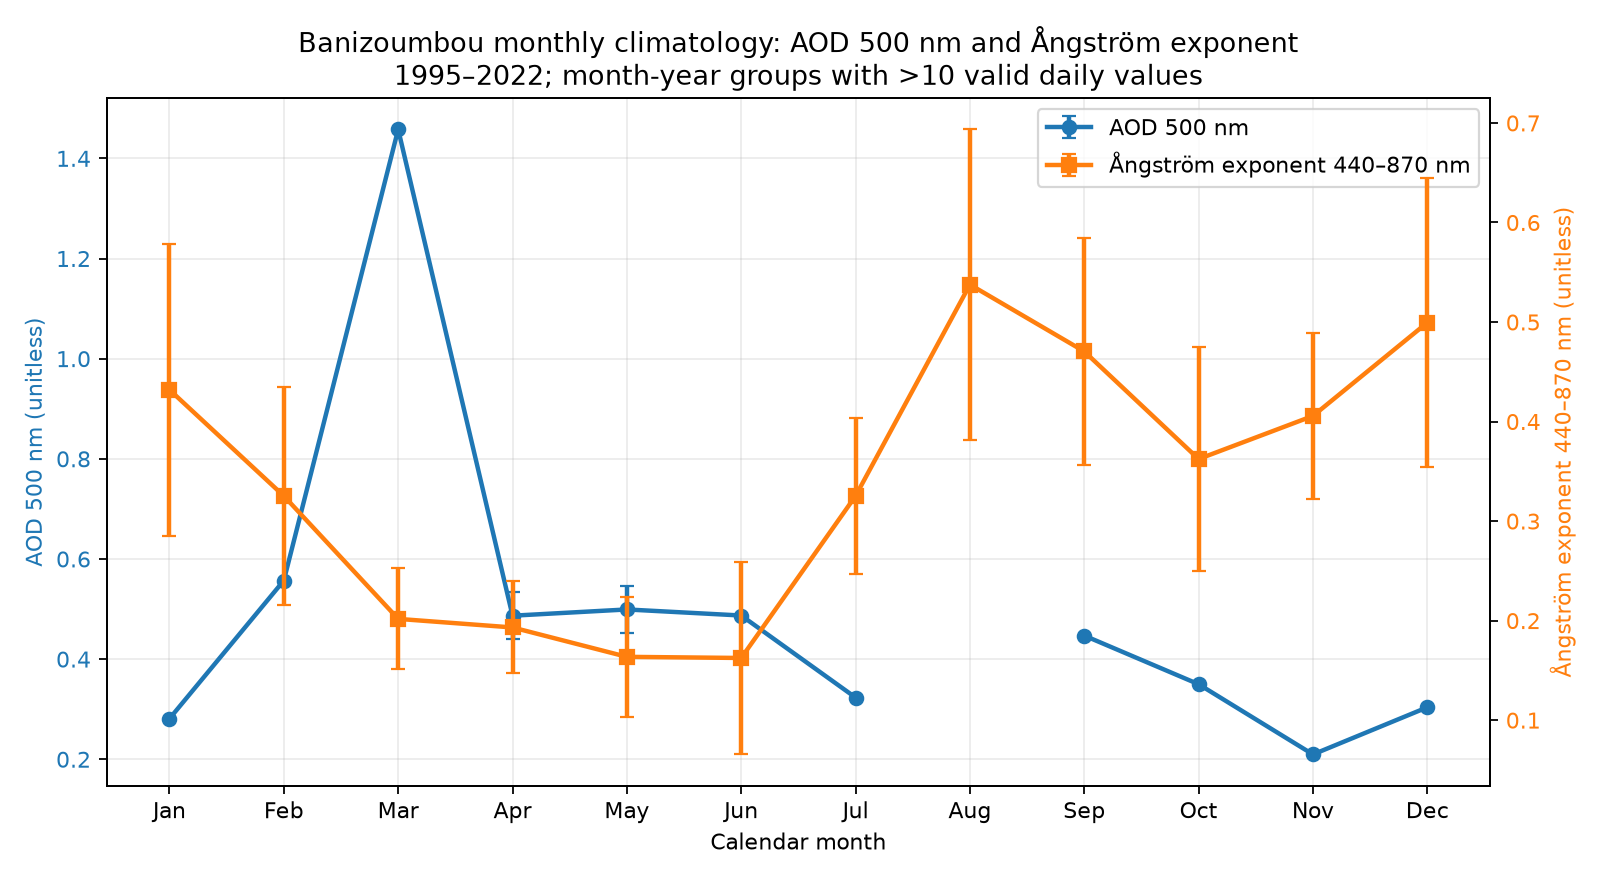

**Site PI acknowledgment:** Jean-Louis Rajot, Banizoumbou site PI.

In [16]:
answer(r)

In [17]:
show_turns()

,turn,asked,status,question,summary,variables,kernel_note,requests,tool_calls,input_tokens,cache_read,output_tokens,cost
0,1,2026-09-28T04:07:22+00:00,ok,Which five sites have the longest AOD 500 nm r...,"tools: list_sites×1, describe_columns×5, run_p...","[{""name"": ""ranked"", ""meaning"": ""Top five sites...",None,5,8,39189,27873,1796,0.006063
1,2,2026-09-28T04:07:36+00:00,ok,"For the top one of those, what is its mean AOD...",tools: run_python×2 | files: mauna_loa_annual_...,[],None,3,2,18355,10690,2053,0.005033
2,3,2026-09-28T04:07:58+00:00,ok,Show the monthly climatology of AOD 500 nm and...,"tools: list_sites×1, describe_columns×1, run_p...",[],None,6,5,49095,37102,2825,0.007803


In [18]:
sb.stop(CONVERSATION_ID)      # stands in for 60 idle minutes: variables gone, files kept

In [19]:
r = await ask("What do we have so far, and what is left in the sandbox?")

=== What do we have so far, and what is left in the sandbox?
    (3 earlier turns in context; conversation so far $0.0189)

--- step 1: to model
  >>> USER        : ### sandbox state now
kernel: restarted (no reason recorded: memory limit, host restart or stopped by hand); every earlier variable is gone, files in /workspace are kept
variables: none
files in /workspace: banizoumbou_monthly_climatology_aod500_ae440_870.csv, banizoumbou_monthly_climatology_aod500_ae440_870.png, longest_aod500_records.csv, mauna_loa_annual_mean_aod500.csv
memory used: 202 of 2147 MB; storage used: 0.15 of 1000 MB in /workspace

### question
What do we have so far, and what is left in the sandbox?
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll verify the current sandbox inventory and memory state, then summarize the completed analyses and remaining files.
  --> TOOL CALL   : kernel_state({})
      in 6516 (cache read 0, write 6395) | out 61 (reasoning 18) | $0.0019

--- step 2

In [20]:
answer(r)

## Sandbox status

The kernel was restarted, so **no Python variables remain in memory**. The files in `/workspace` survived.

### Analyses completed

1. **Five longest AOD 500 nm records**
   - Ranked sites by the number of non-missing daily `AOD_500nm` values.
   - Output table saved as `longest_aod500_records.csv`.

2. **Mauna_Loa annual mean AOD 500 nm**
   - Used the top-ranked site, Mauna_Loa.
   - Applied the climatology rule of at least 5 valid daily values per month and at least 9 qualifying months per year.
   - Output table saved as `mauna_loa_annual_mean_aod500.csv`.

3. **Banizoumbou monthly climatology**
   - Calculated monthly climatologies for AOD 500 nm and the reported Ångström exponent 440–870 nm.
   - Saved both a table and figure.
   - The AOD 500 nm record was sparse at Banizoumbou, so its monthly climatology represented mainly 2021–2022 rather than the full site record.

### Files remaining

| File | Contents |
|---|---|
| `longest_aod500_records.csv` | Five sites with the longest valid AOD 500 nm records |
| `mauna_loa_annual_mean_aod500.csv` | Annual Mauna_Loa mean AOD 500 nm |
| `banizoumbou_monthly_climatology_aod500_ae440_870.csv` | Banizoumbou monthly AOD and Ångström exponent climatology |
| `banizoumbou_monthly_climatology_aod500_ae440_870.png` | Banizoumbou monthly climatology figure |

### Current resource state

- **In-memory variables:** none
- **Memory used:** 202 MB of 2,147 MB
- **Workspace used:** approximately 0.15 MB of 1,000 MB
- **Source data:** `/data/aeronet.parquet` remains available for new analyses

Nothing is currently left as an unfinished computation; further questions would require rebuilding any needed data objects from the parquet source or the saved CSV files.

## 10 · Resume tomorrow

Nothing to save: the store already has every turn. Run sections 1–8 with the same `CONVERSATION_ID` and ask the next
question; `history_for_model()` finds the earlier turns, `ensure_running()` starts a fresh sandbox on the same
folder and tells the model the variables are gone.

In [21]:
show_turns()

,turn,asked,status,question,summary,variables,kernel_note,requests,tool_calls,input_tokens,cache_read,output_tokens,cost
0,1,2026-09-28T04:07:22+00:00,ok,Which five sites have the longest AOD 500 nm r...,"tools: list_sites×1, describe_columns×5, run_p...","[{""name"": ""ranked"", ""meaning"": ""Top five sites...",NaN,5,8,39189,27873,1796,0.006063
1,2,2026-09-28T04:07:36+00:00,ok,"For the top one of those, what is its mean AOD...",tools: run_python×2 | files: mauna_loa_annual_...,[],NaN,3,2,18355,10690,2053,0.005033
2,3,2026-09-28T04:07:58+00:00,ok,Show the monthly climatology of AOD 500 nm and...,"tools: list_sites×1, describe_columns×1, run_p...",[],NaN,6,5,49095,37102,2825,0.007803
3,4,2026-09-28T04:08:07+00:00,ok,"What do we have so far, and what is left in th...",tools: kernel_state×1,[],"restarted (no reason recorded: memory limit, h...",2,1,13215,6395,647,0.002857


In [22]:
# the full trace of one turn, message by message
turn = 1
messages = ModelMessagesTypeAdapter.validate_json(
    DB.execute("SELECT messages FROM turns WHERE conversation=? AND turn=?", (CONVERSATION_ID, turn)).fetchone()[0])
for m in messages:
    for p in m.parts: show_part(p)

  >>> USER        : ### sandbox state now
variables: none
files from recent turns: none
memory used: 203 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace

### question
Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
  ... THINKING    : <no text>
  <<< ANSWER      : I’ll first identify the longest-record sites, then verify which of those have AOD 500 nm and count its valid daily observations.
  --> TOOL CALL   : list_sites({"limit":10})
  <-- TOOL RESULT : list_sites -> 1485 site(s) match, showing the 10 with the longest records
                      lat      lon  elev_m       first        last  days
AERONET_Site_Name                                                       
Mauna_Loa          19.536 -155.577    3402  1994-06-03  2026-07-07  9198
GSFC               38.992  -76.840      87  1993-05-14  2026-01-08  8234
SEDE_BOKER         30.855   34.782     480  1995-08-11  2025-04-04  7767
Ispra              45.803    8.627     235  199

## 11 · Cleanup

In [23]:
sb.stop(CONVERSATION_ID)